In [131]:
#Installing python libraries to notebook
!mamba install pandas numpy matplotlib seaborn scikit-learn

mambajs 0.19.13

Specs: xeus-python, numpy, matplotlib, pillow, ipywidgets>=8.1.6, ipyleaflet, scipy, pandas, seaborn, scikit-learn
Channels: emscripten-forge, conda-forge

Solving environment...
Solving took 1.5835 seconds
All requested packages already installed.


In [132]:
#Importing Libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [133]:
#Saving data to dataframe
df = pd.read_csv("NYPD_Arrest_Data_(Year_to_Date)_20260506.csv")

In [134]:
#Getting to know the data
df.head()

,ARREST_KEY,ARREST_DATE,PD_CD,PD_DESC,KY_CD,OFNS_DESC,LAW_CODE,LAW_CAT_CD,ARREST_BORO,ARREST_PRECINCT,JURISDICTION_CODE,AGE_GROUP,PERP_SEX,PERP_RACE,X_COORD_CD,Y_COORD_CD,Latitude,Longitude,Location
0,318451126,01/06/2026,105.0,STRANGULATION 1ST,106.0,FELONY ASSAULT,PL 1211200,F,Q,110,0,25-44,M,BLACK,1020232,210719,40.744989,-73.870145,POINT (-73.870145 40.744989)
1,318308486,01/03/2026,203.0,"TRESPASS 3, CRIMINAL",352.0,CRIMINAL TRESPASS,PL 140100G,M,K,77,1,25-44,M,BLACK,1003358,182945,40.668798,-73.931120,POINT (-73.93112014 40.66879784)
2,318550123,01/08/2026,105.0,STRANGULATION 1ST,106.0,FELONY ASSAULT,PL 1211200,F,B,48,0,25-44,M,WHITE HISPANIC,1011780,246837,40.844152,-73.900500,POINT (-73.9005 40.844152)
3,318580867,01/07/2026,397.0,"ROBBERY,OPEN AREA UNCLASSIFIED",105.0,ROBBERY,PL 160102B,F,M,28,0,(null),(null),BLACK,999788,233328,40.807102,-73.943874,POINT (-73.943874 40.807102)
4,318684449,01/10/2026,397.0,"ROBBERY,OPEN AREA UNCLASSIFIED",105.0,ROBBERY,PL 160102A,F,B,45,0,<18,F,BLACK,1031351,254245,40.864401,-73.829711,POINT (-73.829711 40.864401)


In [135]:
df.columns

Index(['ARREST_KEY', 'ARREST_DATE', 'PD_CD', 'PD_DESC', 'KY_CD', 'OFNS_DESC',
       'LAW_CODE', 'LAW_CAT_CD', 'ARREST_BORO', 'ARREST_PRECINCT',
       'JURISDICTION_CODE', 'AGE_GROUP', 'PERP_SEX', 'PERP_RACE', 'X_COORD_CD',
       'Y_COORD_CD', 'Latitude', 'Longitude', 'Location'],
      dtype='str')

In [136]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 69305 entries, 0 to 69304
Data columns (total 19 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   ARREST_KEY         69305 non-null  int64  
 1   ARREST_DATE        69305 non-null  str    
 2   PD_CD              69303 non-null  float64
 3   PD_DESC            69305 non-null  str    
 4   KY_CD              69293 non-null  float64
 5   OFNS_DESC          69305 non-null  str    
 6   LAW_CODE           69305 non-null  str    
 7   LAW_CAT_CD         69038 non-null  str    
 8   ARREST_BORO        69305 non-null  str    
 9   ARREST_PRECINCT    69305 non-null  int64  
 10  JURISDICTION_CODE  69305 non-null  int64  
 11  AGE_GROUP          69305 non-null  str    
 12  PERP_SEX           69305 non-null  str    
 13  PERP_RACE          69305 non-null  str    
 14  X_COORD_CD         69305 non-null  int64  
 15  Y_COORD_CD         69305 non-null  int64  
 16  Latitude           69305 non-null

In [137]:
#Identify missing data and clean up
df = df.replace('(null)', pd.NA)
df.isna()

,ARREST_KEY,ARREST_DATE,PD_CD,PD_DESC,KY_CD,OFNS_DESC,LAW_CODE,LAW_CAT_CD,ARREST_BORO,ARREST_PRECINCT,JURISDICTION_CODE,AGE_GROUP,PERP_SEX,PERP_RACE,X_COORD_CD,Y_COORD_CD,Latitude,Longitude,Location
0,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False,True,True,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
69300,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
69301,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
69302,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
69303,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False


In [138]:
df.isna().sum()

ARREST_KEY               0
ARREST_DATE              0
PD_CD                    2
PD_DESC                 12
KY_CD                   12
OFNS_DESC               12
LAW_CODE                 2
LAW_CAT_CD             269
ARREST_BORO              0
ARREST_PRECINCT          0
JURISDICTION_CODE        0
AGE_GROUP            16933
PERP_SEX             16933
PERP_RACE                0
X_COORD_CD               0
Y_COORD_CD               0
Latitude                 0
Longitude                0
Location                 0
dtype: int64

In [139]:
df2 = df.dropna(subset=['AGE_GROUP', 'PERP_SEX'])

In [140]:
df2.head()

,ARREST_KEY,ARREST_DATE,PD_CD,PD_DESC,KY_CD,OFNS_DESC,LAW_CODE,LAW_CAT_CD,ARREST_BORO,ARREST_PRECINCT,JURISDICTION_CODE,AGE_GROUP,PERP_SEX,PERP_RACE,X_COORD_CD,Y_COORD_CD,Latitude,Longitude,Location
0,318451126,01/06/2026,105.0,STRANGULATION 1ST,106.0,FELONY ASSAULT,PL 1211200,F,Q,110,0,25-44,M,BLACK,1020232,210719,40.744989,-73.870145,POINT (-73.870145 40.744989)
1,318308486,01/03/2026,203.0,"TRESPASS 3, CRIMINAL",352.0,CRIMINAL TRESPASS,PL 140100G,M,K,77,1,25-44,M,BLACK,1003358,182945,40.668798,-73.931120,POINT (-73.93112014 40.66879784)
2,318550123,01/08/2026,105.0,STRANGULATION 1ST,106.0,FELONY ASSAULT,PL 1211200,F,B,48,0,25-44,M,WHITE HISPANIC,1011780,246837,40.844152,-73.900500,POINT (-73.9005 40.844152)
4,318684449,01/10/2026,397.0,"ROBBERY,OPEN AREA UNCLASSIFIED",105.0,ROBBERY,PL 160102A,F,B,45,0,<18,F,BLACK,1031351,254245,40.864401,-73.829711,POINT (-73.829711 40.864401)
5,318772893,01/12/2026,263.0,"ARSON 2,3,4",114.0,ARSON,PL 1501001,F,M,28,0,25-44,M,BLACK,998296,234474,40.810250,-73.949261,POINT (-73.949261 40.81025)


In [141]:
#Narrow down to relevant data
df3 = df2.drop(columns = ['X_COORD_CD', 'Y_COORD_CD', 'Latitude', 'Longitude', 'Location', 'PD_CD', 'KY_CD', 'LAW_CODE', 'LAW_CAT_CD'])

In [142]:
df3.head()

,ARREST_KEY,ARREST_DATE,PD_DESC,OFNS_DESC,ARREST_BORO,ARREST_PRECINCT,JURISDICTION_CODE,AGE_GROUP,PERP_SEX,PERP_RACE
0,318451126,01/06/2026,STRANGULATION 1ST,FELONY ASSAULT,Q,110,0,25-44,M,BLACK
1,318308486,01/03/2026,"TRESPASS 3, CRIMINAL",CRIMINAL TRESPASS,K,77,1,25-44,M,BLACK
2,318550123,01/08/2026,STRANGULATION 1ST,FELONY ASSAULT,B,48,0,25-44,M,WHITE HISPANIC
4,318684449,01/10/2026,"ROBBERY,OPEN AREA UNCLASSIFIED",ROBBERY,B,45,0,<18,F,BLACK
5,318772893,01/12/2026,"ARSON 2,3,4",ARSON,M,28,0,25-44,M,BLACK


In [143]:
df3["OFNS_DESC"].unique()

<StringArray>
[                  'FELONY ASSAULT',                'CRIMINAL TRESPASS',
                          'ROBBERY',                            'ARSON',
                         'GAMBLING',                                nan,
     'ASSAULT 3 & RELATED OFFENSES',                             'RAPE',
                       'SEX CRIMES',                         'BURGLARY',
            'ANTICIPATORY OFFENSES',              'ADMINISTRATIVE CODE',
                  'DANGEROUS DRUGS',          'MISCELLANEOUS PENAL LAW',
                    'PETIT LARCENY',                'DANGEROUS WEAPONS',
         'OFFENSES INVOLVING FRAUD',                 'OTHER STATE LAWS',
   'OFFENSES AGAINST PUBLIC ADMINI',    'POSSESSION OF STOLEN PROPERTY',
   'CRIMINAL MISCHIEF & RELATED OF',         'VEHICLE AND TRAFFIC LAWS',
  'OTHER OFFENSES RELATED TO THEFT',                    'GRAND LARCENY',
                          'FORGERY',    'OFF. AGNST PUB ORD SENSBLTY &',
   'INTOXICATED & IMPAIRED DRIVING', 

In [144]:
df3["OFNS_DESC"].value_counts()

OFNS_DESC
ASSAULT 3 & RELATED OFFENSES        7586
PETIT LARCENY                       4985
FELONY ASSAULT                      4670
DANGEROUS DRUGS                     4389
MISCELLANEOUS PENAL LAW             3945
VEHICLE AND TRAFFIC LAWS            2700
CRIMINAL MISCHIEF & RELATED OF      2302
ROBBERY                             2131
GRAND LARCENY                       1988
OFFENSES AGAINST PUBLIC ADMINI      1942
DANGEROUS WEAPONS                   1841
OTHER OFFENSES RELATED TO THEFT     1718
OTHER STATE LAWS                    1594
BURGLARY                            1472
SEX CRIMES                          1424
OFF. AGNST PUB ORD SENSBLTY &       1102
FORGERY                              756
CRIMINAL TRESPASS                    709
INTOXICATED & IMPAIRED DRIVING       690
POSSESSION OF STOLEN PROPERTY        683
OTHER TRAFFIC INFRACTION             450
MURDER & NON-NEGL. MANSLAUGHTE       402
OFFENSES AGAINST THE PERSON          349
OFFENSES INVOLVING FRAUD             329
FRAUDS

In [145]:
#Identify data to compare
burglary_df = df3[df3["PD_DESC"].str.contains("BURGLARY",case=False, na=False)]

In [146]:
burglary_df.head()

,ARREST_KEY,ARREST_DATE,PD_DESC,OFNS_DESC,ARREST_BORO,ARREST_PRECINCT,JURISDICTION_CODE,AGE_GROUP,PERP_SEX,PERP_RACE
23,321157325,03/02/2026,"BURGLARY,RESIDENCE,NIGHT",BURGLARY,B,50,0,45-64,M,WHITE
26,321592435,03/10/2026,"BURGLARY,UNCLASSIFIED,UNKNOWN",BURGLARY,M,19,0,45-64,M,BLACK
74,319309850,01/22/2026,"BURGLARY,UNCLASSIFIED,UNKNOWN",BURGLARY,M,13,0,25-44,M,BLACK
76,318645763,01/09/2026,"BURGLARY,UNCLASSIFIED,UNKNOWN",BURGLARY,B,40,2,25-44,F,BLACK
213,318320552,01/03/2026,"BURGLARY,UNCLASSIFIED,UNKNOWN",BURGLARY,M,13,0,25-44,M,BLACK


In [147]:
borough_df = burglary_df[burglary_df["ARREST_BORO"].isin(["Q","M"])]

In [148]:
borough_df.head()

,ARREST_KEY,ARREST_DATE,PD_DESC,OFNS_DESC,ARREST_BORO,ARREST_PRECINCT,JURISDICTION_CODE,AGE_GROUP,PERP_SEX,PERP_RACE
26,321592435,03/10/2026,"BURGLARY,UNCLASSIFIED,UNKNOWN",BURGLARY,M,19,0,45-64,M,BLACK
74,319309850,01/22/2026,"BURGLARY,UNCLASSIFIED,UNKNOWN",BURGLARY,M,13,0,25-44,M,BLACK
213,318320552,01/03/2026,"BURGLARY,UNCLASSIFIED,UNKNOWN",BURGLARY,M,13,0,25-44,M,BLACK
292,319375257,01/23/2026,"BURGLARY,UNCLASSIFIED,UNKNOWN",BURGLARY,M,19,0,18-24,F,BLACK
296,318468404,01/06/2026,"BURGLARY,UNCLASSIFIED,UNKNOWN",BURGLARY,M,32,0,25-44,F,WHITE


In [149]:
borough_df["ARREST_BORO"].value_counts()

ARREST_BORO
M    505
Q    237
Name: count, dtype: int64

<Axes: title={'center': 'Burglary Arrest Comparison b/w Manhatten & Queens'}, xlabel='ARREST_BORO'>

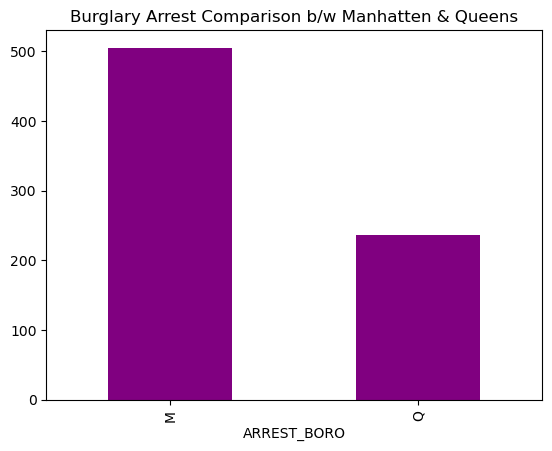

In [150]:
#Add Visulizations
borough_compare = borough_df["ARREST_BORO"].value_counts()
borough_compare.plot(kind="bar", color=['purple'], title='Burglary Arrest Comparison b/w Manhatten & Queens')

In [151]:
race_compare = borough_df.groupby(["PERP_RACE", "ARREST_BORO"]).size().reset_index(name="Count")

In [152]:
race_compare.value_counts()

PERP_RACE                       ARREST_BORO  Count
AMERICAN INDIAN/ALASKAN NATIVE  M            1        1
ASIAN / PACIFIC ISLANDER        M            11       1
                                Q            18       1
BLACK                           M            208      1
                                Q            82       1
BLACK HISPANIC                  M            64       1
                                Q            11       1
UNKNOWN                         M            3        1
WHITE                           M            76       1
                                Q            33       1
WHITE HISPANIC                  M            142      1
                                Q            93       1
Name: count, dtype: int64

<Axes: xlabel='PERP_RACE', ylabel='Count'>

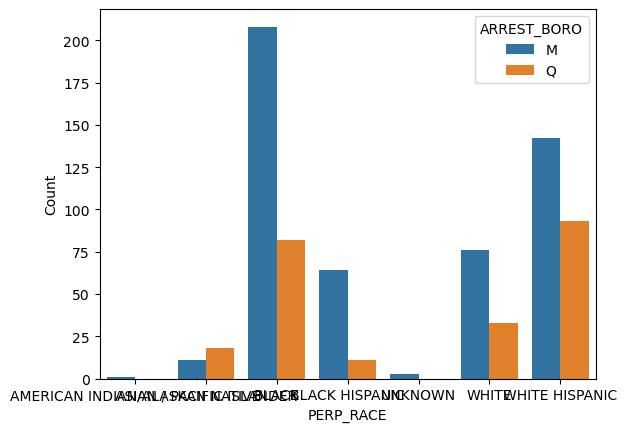

In [153]:
sns.barplot(data= race_compare, x="PERP_RACE", y="Count", hue="ARREST_BORO")

In [154]:
age_compare = borough_df.groupby(["AGE_GROUP", "ARREST_BORO"]).size().reset_index(name="Count")

<Axes: xlabel='AGE_GROUP', ylabel='Count'>

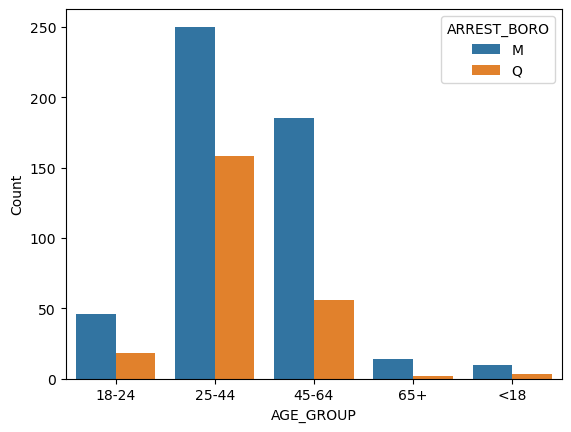

In [155]:
sns.barplot(data= age_compare, x="AGE_GROUP", y="Count", hue="ARREST_BORO")

In [156]:
#Conclusion
#The NYPD data analyzed identifies that there are more burglaries that occur in Manahatten than there are in Queens.
#In Manhatten the data support that the crime occurs more often by Black perpetrators and people in the age group 25-44.
#However in Queens the most common perpertrator are white hispanics while the age group remains the same.
#This could be impacted by the demographics of the respective areas.